In [85]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

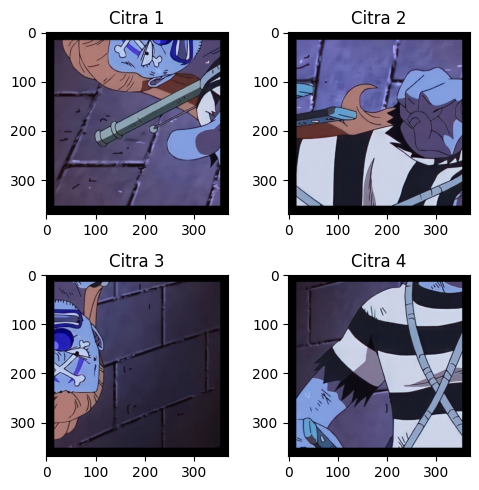

In [86]:
img1 = cv2.imread('assets/buggy1.png')
img2 = cv2.imread('assets/buggy2.png')
img3 = cv2.imread('assets/buggy3.png')
img4 = cv2.imread('assets/buggy4.png')

plt.figure(figsize=(5, 5))
plt.subplot(2,2,1); plt.imshow(img1); plt.title('Citra 1')
plt.subplot(2,2,2); plt.imshow(img2); plt.title('Citra 2')
plt.subplot(2,2,3); plt.imshow(img3); plt.title('Citra 3')
plt.subplot(2,2,4); plt.imshow(img4); plt.title('Citra 4')
plt.tight_layout(); plt.show()

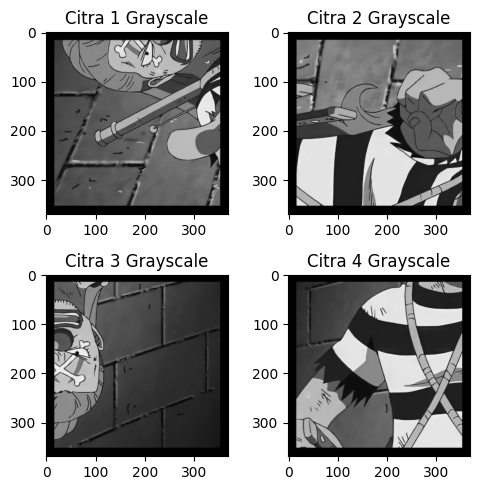

In [87]:
g1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
g2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
g3 = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)
g4 = cv2.cvtColor(img4, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(5, 5))
plt.subplot(2,2,1); plt.imshow(g1, cmap='gray'); plt.title('Citra 1 Grayscale')
plt.subplot(2,2,2); plt.imshow(g2, cmap='gray'); plt.title('Citra 2 Grayscale')
plt.subplot(2,2,3); plt.imshow(g3, cmap='gray'); plt.title('Citra 3 Grayscale')
plt.subplot(2,2,4); plt.imshow(g4, cmap='gray'); plt.title('Citra 4 Grayscale')
plt.tight_layout(); plt.show()

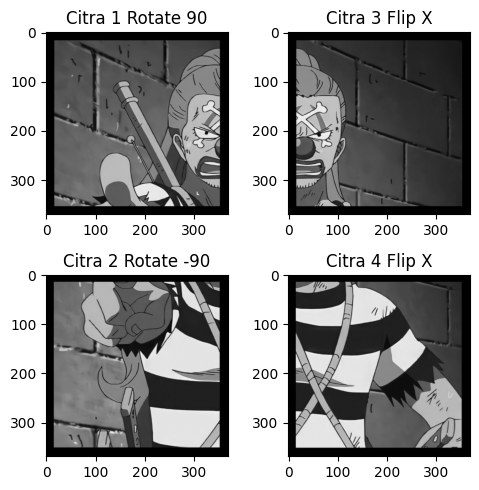

In [88]:
def rotate(image, val):
    h, w = image.shape
    val = int(val) % 360
    if val == 0: return image
    elif val == 90:
        rot = np.zeros((w, h), dtype=image.dtype)
        for i in range(h):
            for j in range(w): rot[j, h - 1 - i] = image[i, j]
        return rot
    elif val == 180:
        rot = np.zeros_like(image, dtype=image.dtype)
        for i in range(h):
            for j in range(w): rot[h - 1 - i, w - 1 - j] = image[i, j]
        return rot
    elif val == 270:
        rot = np.zeros((w, h), dtype=image.dtype)
        for i in range(h):
            for j in range(w): rot[w - 1 - j, i] = image[i, j]
        return rot
    return image

def flip(image, mode='X'):
    h, w = image.shape
    hasil = np.zeros((h, w), dtype=image.dtype)
    for i in range(h):
        for j in range(w):
            if mode == 'X':
                hasil[i, j] = image[i, w - 1 - j]
            elif mode == 'Y':
                hasil[i, j] = image[h - 1 - i, j]
    return hasil

r1 = rotate(g1, 90)
r2 = rotate(g2, -90)
r3 = rotate(g3, 180)
f3 = flip(r3,mode='X')
f4 = flip(g4,'X')

plt.figure(figsize=(5, 5))
plt.subplot(2,2,1); plt.imshow(r1, cmap='gray'); plt.title('Citra 1 Rotate 90')
plt.subplot(2,2,2); plt.imshow(f3, cmap='gray'); plt.title('Citra 3 Flip X')
plt.subplot(2,2,3); plt.imshow(r2, cmap='gray'); plt.title('Citra 2 Rotate -90')
plt.subplot(2,2,4); plt.imshow(f4, cmap='gray'); plt.title('Citra 4 Flip X')
plt.tight_layout(); plt.show()


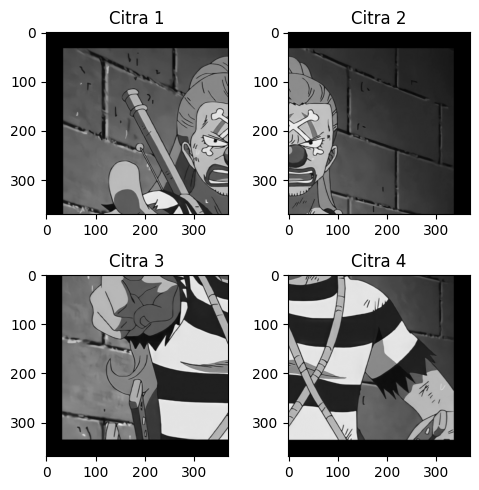

In [94]:
def t(image, geser_kolom_x=0, geser_baris_y=0):
    image = np.array(image)
    h, w = image.shape[:2]  # ✅ fix shape
    hasil = np.zeros((h, w), dtype=image.dtype)
    for i in range(h):
        for j in range(w):
            new_i = i + geser_baris_y
            new_j = j + geser_kolom_x
            if 0 <= new_i < h and 0 <= new_j < w:
                hasil[new_i, new_j] = image[i, j]
    return hasil

t1 = t(r1, geser_kolom_x=18,  geser_baris_y=16)
t2 = t(f3, geser_kolom_x=-17, geser_baris_y=16)
t3 = t(r2, geser_kolom_x=17,  geser_baris_y=-16)
t4 = t(f4, geser_kolom_x=-16, geser_baris_y=-16)

fig, axes = plt.subplots(2, 2, figsize=(5, 5))

axes[0, 0].imshow(t1, cmap='gray'); axes[0, 0].set_title('Citra 1')
axes[0, 1].imshow(t2, cmap='gray'); axes[0, 1].set_title('Citra 2') 
axes[1, 0].imshow(t3, cmap='gray'); axes[1, 0].set_title('Citra 3')  
axes[1, 1].imshow(t4, cmap='gray'); axes[1, 1].set_title('Citra 4')

plt.tight_layout()
plt.show()

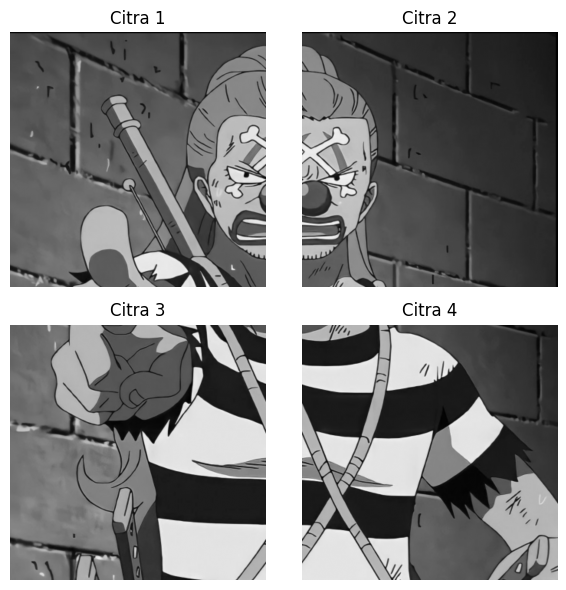

In [97]:
def c(image, p1=0, p2=0, p3=0, p4=0):
    h, w = image.shape[:2]
    dilated = np.zeros((h * 2, w * 2), dtype=np.uint8)
    for y in range(h * 2):
        for x in range(w * 2):
            dilated[y][x] = image[int(y / 2)][int(x / 2)]
    sy, ey = max(0, p1), min(h * 2, h * 2 - p2)
    sx, ex = max(0, p3), min(w * 2, w * 2 - p4)
    return dilated[sy:ey, sx:ex]

c1 = c(t1, p1=60,p2=0,p3=70,p4=0)
c2 = c(t2, p1=60,p2=0,p3=0,p4=60)  
c3 = c(t3, p1=0,p2=70,p3=70,p4=0) 
c4 = c(t4, p1=0,p2=70,p3=0,p4=70)     

# Samakan ukuran agar sambungan pas
target_h = min(c1.shape[0], c2.shape[0], c3.shape[0], c4.shape[0])
target_w = min(c1.shape[1], c2.shape[1], c3.shape[1], c4.shape[1])

c1 = cv2.resize(c1, (target_w, target_h))
c2 = cv2.resize(c2, (target_w, target_h))
c3 = cv2.resize(c3, (target_w, target_h))
c4 = cv2.resize(c4, (target_w, target_h))

fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes[0, 0].imshow(c1, cmap='gray'); axes[0, 0].axis('off'); axes[0, 0].set_title('Citra 1')
axes[0, 1].imshow(c2, cmap='gray'); axes[0, 1].axis('off'); axes[0, 1].set_title('Citra 2')
axes[1, 0].imshow(c3, cmap='gray'); axes[1, 0].axis('off'); axes[1, 0].set_title('Citra 3')
axes[1, 1].imshow(c4, cmap='gray'); axes[1, 1].axis('off'); axes[1, 1].set_title('Citra 4')
plt.tight_layout()
plt.show()

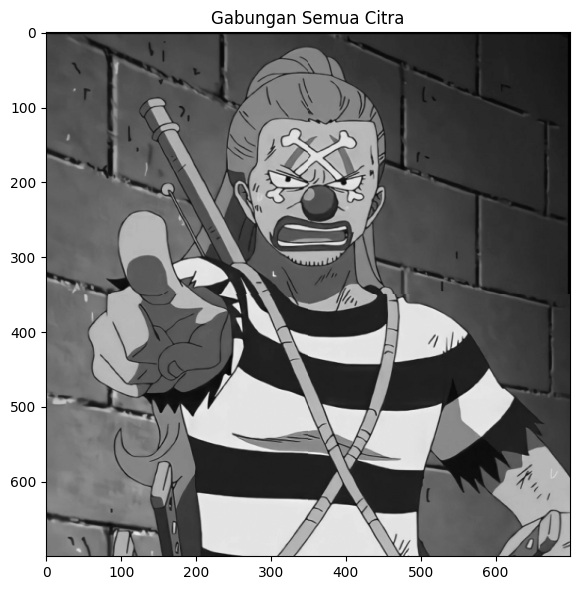

In [98]:
def m(c1, c2, c3, c4):
    baris1 = np.hstack([c1, c2])
    baris2 = np.hstack([c3, c4])

    w = min(baris1.shape[1], baris2.shape[1])
    baris1 = baris1[:, :w]
    baris2 = baris2[:, :w]

    h = min(baris1.shape[0], baris2.shape[0])
    baris1 = baris1[:h, :]
    baris2 = baris2[:h, :]

    return np.vstack([baris1, baris2])

m1 = m(c1, c2, c3, c4) 
m2 = (m1 / 2).astype(np.uint8)
m2 = cv2.resize(m2, (700, 700))

plt.figure(figsize=(6, 6))
plt.imshow(m2, cmap='gray')
plt.title('Gabungan Semua Citra')

plt.tight_layout()
plt.show()

<Figure size 500x500 with 0 Axes>

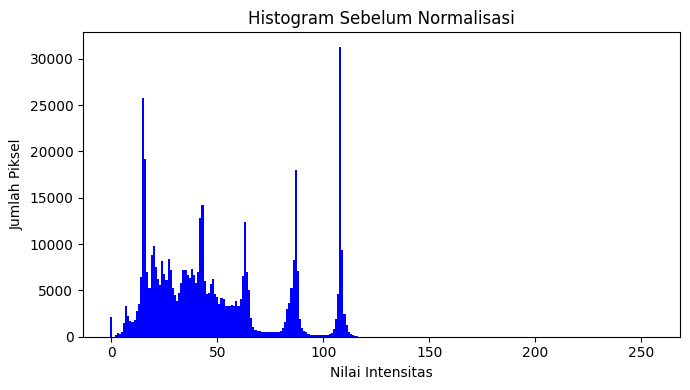

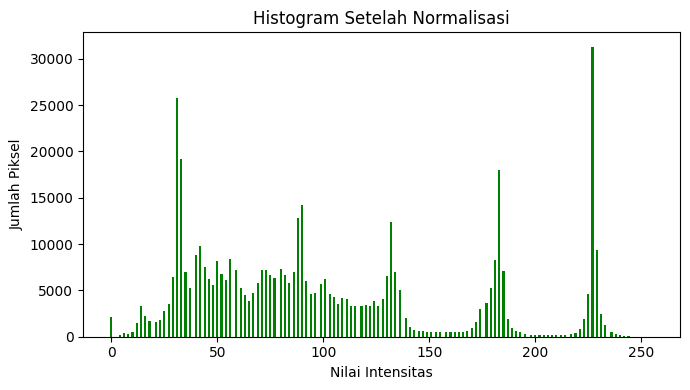

array([ 2097,     0,    18,     0,   195,     0,   359,     0,   271,
           0,   507,     0,  1472,     0,  3349,     0,  2223,     0,
        1648,     0,     0,  1591,     0,  1855,     0,  2829,     0,
        3567,     0,  6391,     0, 25738,     0, 19206,     0,  6941,
           0,  5288,     0,     0,  8788,     0,  9796,     0,  7536,
           0,  6262,     0,  5596,     0,  8146,     0,  6754,     0,
        6106,     0,  8406,     0,     0,  7253,     0,  5249,     0,
        4511,     0,  3845,     0,  4739,     0,  5776,     0,  7164,
           0,  7177,     0,  6709,     0,  6317,     0,     0,  7336,
           0,  6705,     0,  5831,     0,  6952,     0, 12800,     0,
       14168,     0,  5984,     0,  4566,     0,  4763,     0,     0,
        5687,     0,  6207,     0,  4575,     0,  4259,     0,  3563,
           0,  4156,     0,  4110,     0,  3363,     0,  3322,     0,
           0,  3337,     0,  3414,     0,  3298,     0,  3856,     0,
        3335,     0,

In [99]:
def hh(img, title='Histogram', color='blue'):
    hist = np.zeros(256, dtype=np.int64)
    for val in img.flatten():
        hist[int(val)] += 1
    plt.figure(figsize=(7, 4))
    plt.bar(range(256), hist, color=color, width=1)
    plt.title(title)
    plt.xlabel('Nilai Intensitas')
    plt.ylabel('Jumlah Piksel')
    plt.tight_layout(); plt.show()
    return hist

def normalisasi(img):
    img_f = img.astype(np.float64)
    mn, mx = img_f.min(), img_f.max()
    if mx == mn:
        return img.copy()
    return ((img_f - mn) / (mx - mn) * 255).astype(np.uint8)

m2n = normalisasi(m2)

plt.figure(figsize=(5, 5))

hh(m2, 'Histogram Sebelum Normalisasi', color='blue')
hh(m2n, 'Histogram Setelah Normalisasi', color='green')




Melakukan konvolusi... (harap tunggu)


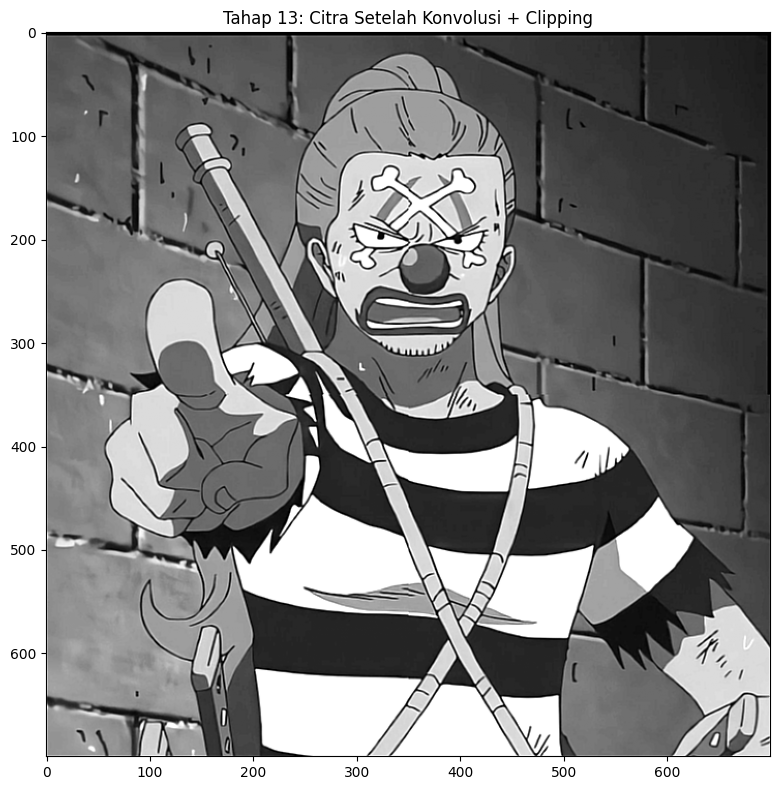

In [100]:
kernel = np.array([
    [-1/10, -1/10, -1/10, -1/10],
    [-1/10,  6/10,  6/10, -1/10],
    [-1/10,  6/10,  6/10, -1/10],
    [-1/10, -1/10, -1/10, -1/10]
])

def k0(img, krn):
    """Konvolusi 2D dengan zero padding same-size."""
    kH, kW   = krn.shape
    pH, pW   = kH // 2, kW // 2
    img_pad  = np.pad(img.astype(np.float64),
                        ((pH, kH - pH - 1), (pW, kW - pW - 1)),
                        mode='constant', constant_values=0)
    H, W     = img.shape
    hasil    = np.zeros((H, W), dtype=np.float64)
    for i in range(H):
        for j in range(W):
            hasil[i, j] = np.sum(img_pad[i:i+kH, j:j+kW] * krn)
    return hasil

print("\nMelakukan konvolusi... (harap tunggu)")
k  = k0(m2n, kernel)
kf  = np.clip(k, 0, 255).astype(np.uint8)

plt.figure(figsize=(8, 8))
plt.imshow(kf, cmap='gray')
plt.title('Tahap 13: Citra Setelah Konvolusi + Clipping')
plt.tight_layout(); plt.show()